# NB06 — Climate Comparison & Final Report

**Goal:** Answer jury-ready questions:
1. Is the forecast **hotter than last year**?
2. Is it **hotter than the decade average** (2015-2024)?
3. Is there a **long-term warming signal**?
4. Will **wildfire risk increase**?
5. Which cities are **highest risk and why**?

**Input:** `outputs/wildfire_risk_30d.parquet`, `data/processed/engineered_daily.parquet`  
**Output:** `reports/figures/climate_*.png`, `reports/metrics/climate_summary.csv`

In [1]:
# ─── Cell 1: Imports & load ──────────────────────────────────────────────
import os, sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))
from src.config import ROOT, PROCESSED, OUTPUTS, CITIES, ENG_DAILY, MASTER_DAILY, RISK_30D

FIGURES = ROOT / "reports" / "figures"
METRICS = ROOT / "reports" / "metrics"
for p in (FIGURES, METRICS): p.mkdir(parents=True, exist_ok=True)

# Load
hist_path = ENG_DAILY if ENG_DAILY.exists() else MASTER_DAILY
hist = pd.read_parquet(hist_path)
hist["Date"] = pd.to_datetime(hist["Date"])
hist = hist.sort_values(["City","Date"])
hist["Year"]  = hist["Date"].dt.year
hist["Month"] = hist["Date"].dt.month

risk = pd.read_parquet(RISK_30D)
risk["Date"] = pd.to_datetime(risk["Date"])

fc_start, fc_end = risk["Date"].min(), risk["Date"].max()
ly_start = fc_start - pd.DateOffset(years=1)
ly_end   = fc_end   - pd.DateOffset(years=1)
fc_months = list(range(fc_start.month, fc_end.month + 1)) or list(range(1,13))

DECADE_START, DECADE_END = 2015, 2024
T_COL = "Temperature_C_mean"

print(f"History : {hist.shape}  {hist['Date'].min().date()} → {hist['Date'].max().date()}")
print(f"Risk    : {risk.shape}  {fc_start.date()} → {fc_end.date()}")
print(f"Comp    : last year {ly_start.date()} → {ly_end.date()} | decade {DECADE_START}-{DECADE_END}")

History : (83440, 267)  2012-01-19 → 2026-04-29
Risk    : (480, 12)  2026-04-30 → 2026-05-29
Comp    : last year 2025-04-30 → 2025-05-29 | decade 2015-2024


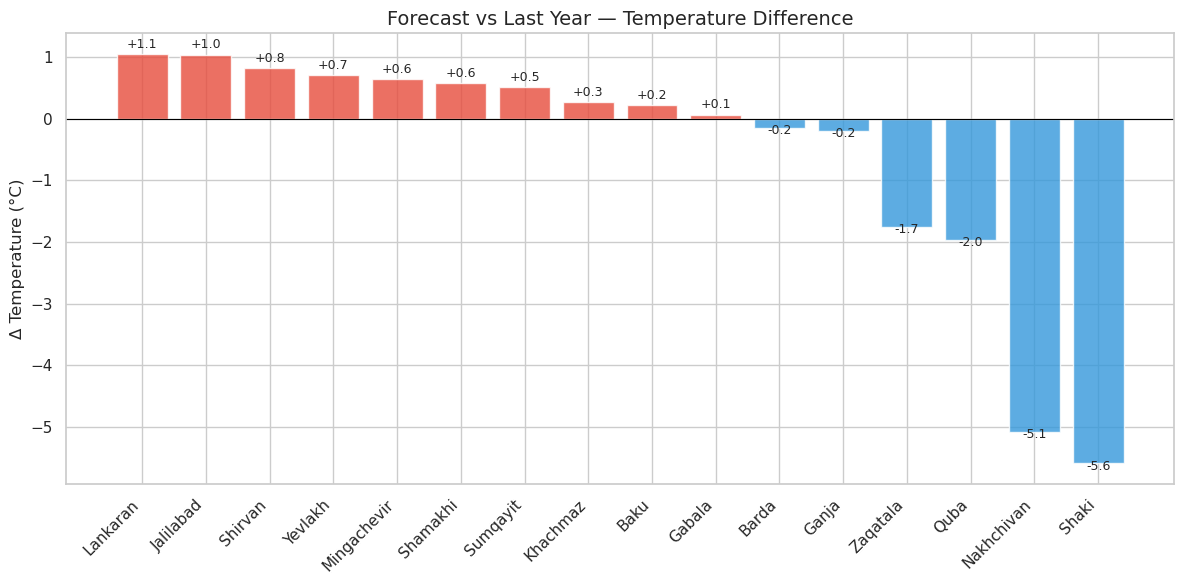

10/16 cities HOTTER than last year (avg -0.55°C)


In [2]:
# ─── §1: Forecast vs Last Year ───────────────────────────────────────────
fc_temp = risk.groupby("City")[T_COL].mean() if T_COL in risk.columns else pd.Series(dtype=float)
ly = hist[(hist["Date"] >= ly_start) & (hist["Date"] <= ly_end)]
ly_temp = ly.groupby("City")[T_COL].mean() if T_COL in ly.columns else pd.Series(dtype=float)

if not fc_temp.empty and not ly_temp.empty:
    comp = pd.DataFrame({"Forecast": fc_temp, "LastYear": ly_temp}).dropna()
    comp["Diff"] = comp["Forecast"] - comp["LastYear"]
    comp = comp.sort_values("Diff", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ["#e74c3c" if d > 0 else "#3498db" for d in comp["Diff"]]
    ax.bar(range(len(comp)), comp["Diff"], color=colors, alpha=0.8)
    ax.set_xticks(range(len(comp))); ax.set_xticklabels(comp.index, rotation=45, ha="right")
    ax.set_ylabel("Δ Temperature (°C)"); ax.axhline(0, color="black", lw=0.8)
    ax.set_title("Forecast vs Last Year — Temperature Difference", fontsize=14)
    for i, v in enumerate(comp["Diff"]): ax.text(i, v+0.1*np.sign(v), f"{v:+.1f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.savefig(FIGURES / "climate_vs_lastyear.png", dpi=150); plt.show()
    comp.to_csv(METRICS / "forecast_vs_lastyear.csv")
    n_hot = (comp["Diff"] > 0).sum()
    print(f"{n_hot}/{len(comp)} cities HOTTER than last year (avg {comp['Diff'].mean():+.2f}°C)")
else:
    print("⚠ Temperature comparison unavailable")

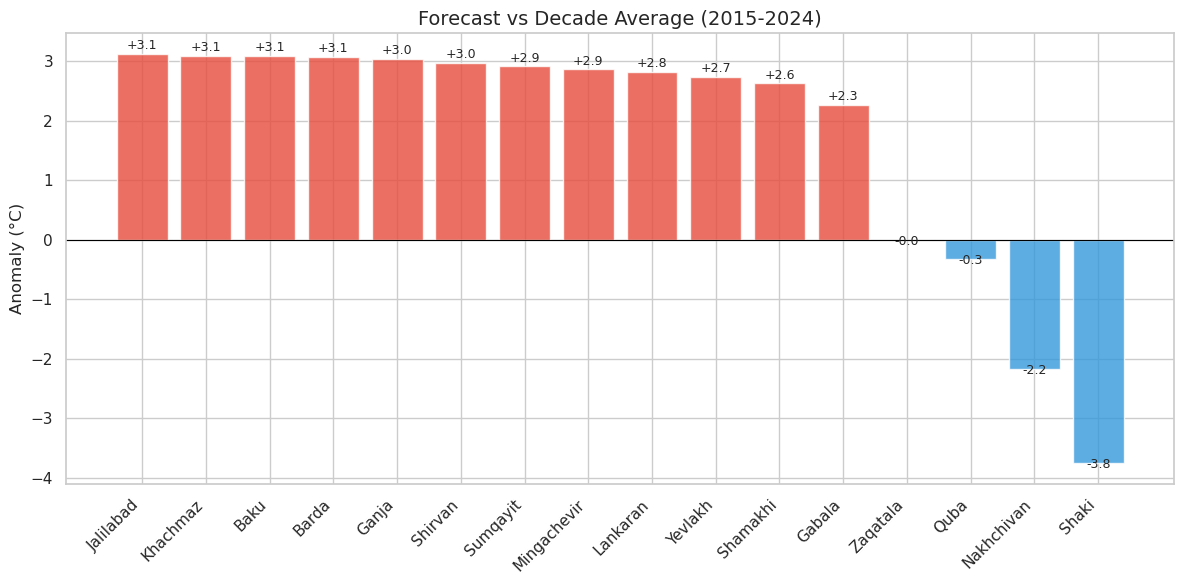

12/16 cities ABOVE decade average (avg anomaly +1.77°C)


In [3]:
# ─── §2: Forecast vs Decade Average ──────────────────────────────────────
decade = hist[(hist["Year"] >= DECADE_START) & (hist["Year"] <= DECADE_END)
              & (hist["Month"].isin(fc_months))]
if T_COL in decade.columns and not fc_temp.empty:
    dec_avg = decade.groupby("City")[T_COL].mean()
    comp2 = pd.DataFrame({"Forecast": fc_temp, "Decade": dec_avg}).dropna()
    comp2["Anomaly"] = comp2["Forecast"] - comp2["Decade"]
    comp2 = comp2.sort_values("Anomaly", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ["#e74c3c" if a > 0 else "#3498db" for a in comp2["Anomaly"]]
    ax.bar(range(len(comp2)), comp2["Anomaly"], color=colors, alpha=0.8)
    ax.set_xticks(range(len(comp2))); ax.set_xticklabels(comp2.index, rotation=45, ha="right")
    ax.set_ylabel("Anomaly (°C)"); ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Forecast vs Decade Average ({DECADE_START}-{DECADE_END})", fontsize=14)
    for i, v in enumerate(comp2["Anomaly"]): ax.text(i, v+0.08*np.sign(v), f"{v:+.1f}", ha="center", fontsize=9)
    plt.tight_layout(); plt.savefig(FIGURES / "climate_vs_decade.png", dpi=150); plt.show()
    comp2.to_csv(METRICS / "forecast_vs_decade.csv")
    print(f"{(comp2['Anomaly']>0).sum()}/{len(comp2)} cities ABOVE decade average "
          f"(avg anomaly {comp2['Anomaly'].mean():+.2f}°C)")
else:
    print("⚠ Decade comparison unavailable")

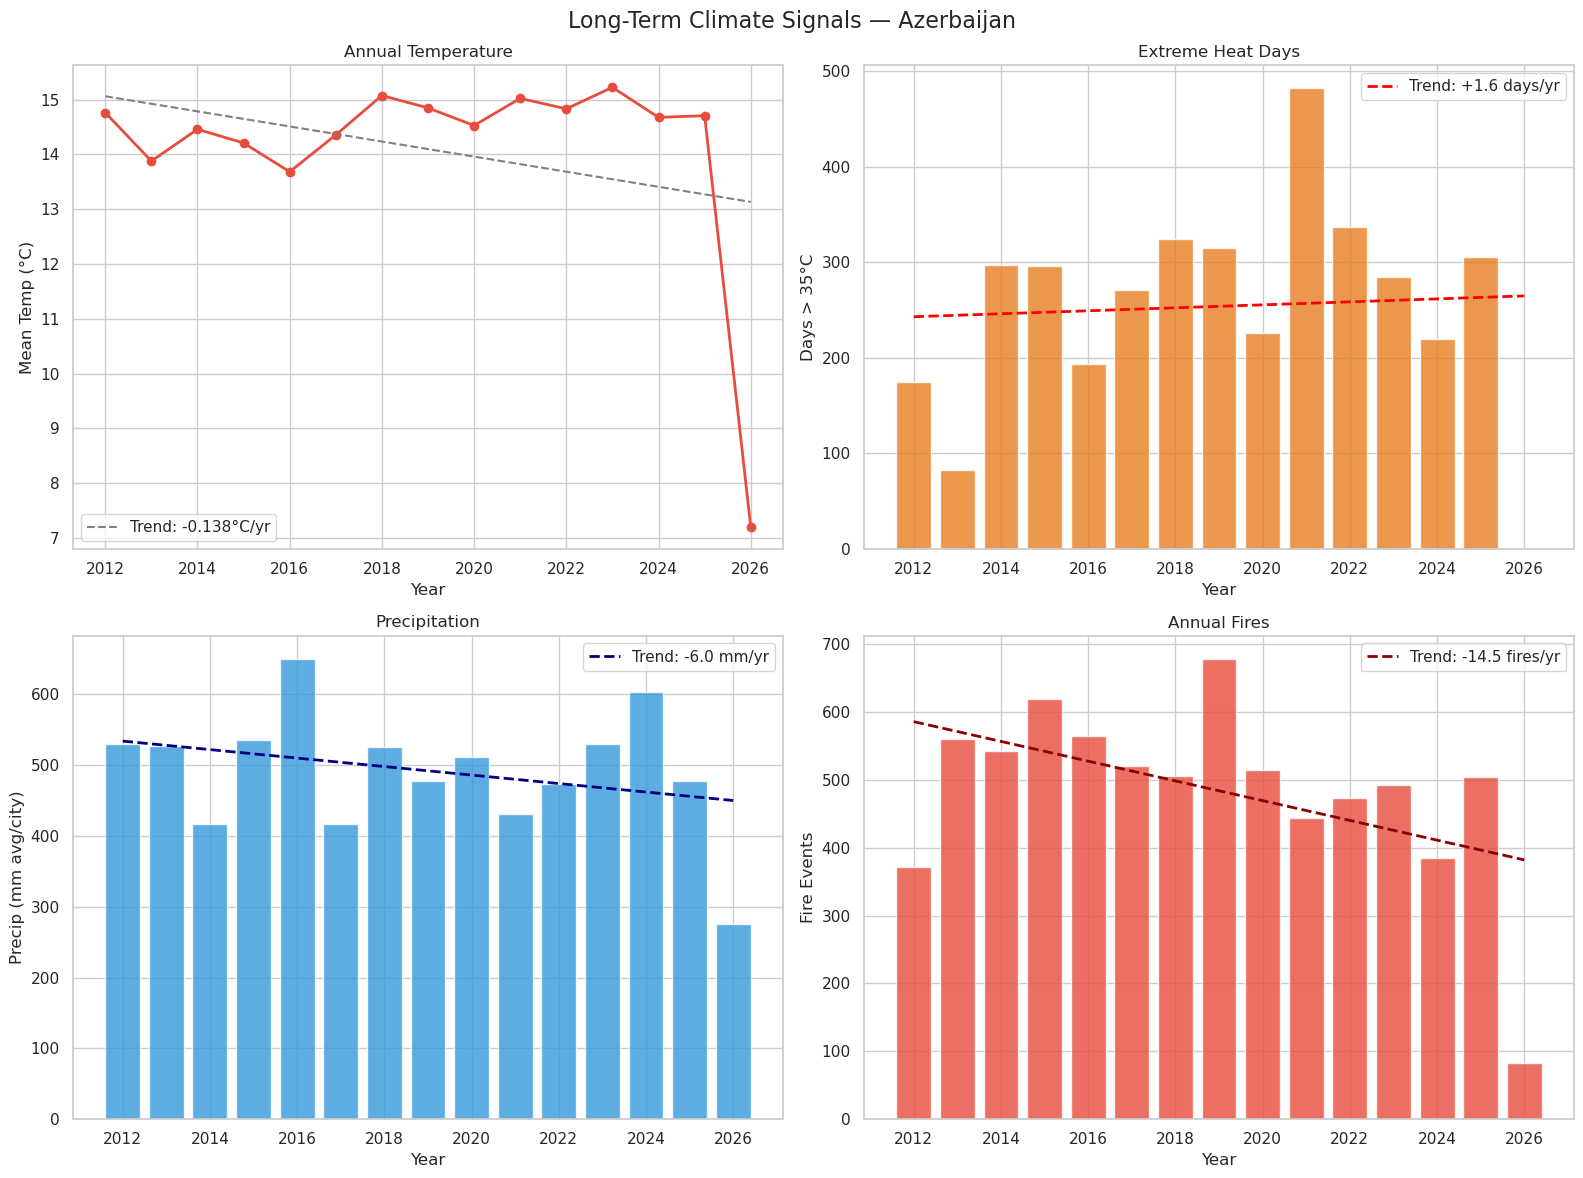

  temp_trend_per_year: -0.1377
  extreme_heat_trend: +1.5571
  precip_trend: -5.9929
  fire_trend: -14.5429


In [4]:
# ─── §3: Long-term climate trends ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Long-Term Climate Signals — Azerbaijan", fontsize=16)
trends = {}

# 3a. Annual temperature
if T_COL in hist.columns:
    yt = hist.groupby("Year")[T_COL].mean()
    ax = axes[0,0]
    ax.plot(yt.index, yt.values, "o-", color="#e74c3c", lw=2)
    z = np.polyfit(yt.index, yt.values, 1); p = np.poly1d(z)
    ax.plot(yt.index, p(yt.index), "--", color="gray", label=f"Trend: {z[0]:+.3f}°C/yr")
    ax.set_xlabel("Year"); ax.set_ylabel("Mean Temp (°C)")
    ax.set_title("Annual Temperature"); ax.legend()
    trends["temp_trend_per_year"] = z[0]

# 3b. Extreme heat days
tmax = "Temperature_C_max"
if tmax in hist.columns:
    hist["_ehd"] = (hist[tmax] > 35).astype(int)
    ye = hist.groupby("Year")["_ehd"].sum()
    ax = axes[0,1]
    ax.bar(ye.index, ye.values, color="#e67e22", alpha=0.8)
    z2 = np.polyfit(ye.index, ye.values, 1)
    ax.plot(ye.index, np.poly1d(z2)(ye.index), "--", color="red", lw=2,
            label=f"Trend: {z2[0]:+.1f} days/yr")
    ax.set_xlabel("Year"); ax.set_ylabel("Days > 35°C")
    ax.set_title("Extreme Heat Days"); ax.legend()
    trends["extreme_heat_trend"] = z2[0]

# 3c. Precipitation
rc = "Rain_mm_sum"
if rc in hist.columns:
    yr = hist.groupby("Year")[rc].sum() / hist.groupby("Year")["City"].nunique()
    ax = axes[1,0]
    ax.bar(yr.index, yr.values, color="#3498db", alpha=0.8)
    z3 = np.polyfit(yr.index, yr.values, 1)
    ax.plot(yr.index, np.poly1d(z3)(yr.index), "--", color="navy", lw=2,
            label=f"Trend: {z3[0]:+.1f} mm/yr")
    ax.set_xlabel("Year"); ax.set_ylabel("Precip (mm avg/city)")
    ax.set_title("Precipitation"); ax.legend()
    trends["precip_trend"] = z3[0]

# 3d. Fire count
if "Fire_Occurred" in hist.columns:
    yf = hist.groupby("Year")["Fire_Occurred"].sum()
    ax = axes[1,1]
    ax.bar(yf.index, yf.values, color="#e74c3c", alpha=0.8)
    z4 = np.polyfit(yf.index, yf.values, 1)
    ax.plot(yf.index, np.poly1d(z4)(yf.index), "--", color="darkred", lw=2,
            label=f"Trend: {z4[0]:+.1f} fires/yr")
    ax.set_xlabel("Year"); ax.set_ylabel("Fire Events")
    ax.set_title("Annual Fires"); ax.legend()
    trends["fire_trend"] = z4[0]

plt.tight_layout(); plt.savefig(FIGURES / "climate_trends.png", dpi=150); plt.show()
for k, v in trends.items(): print(f"  {k}: {v:+.4f}")

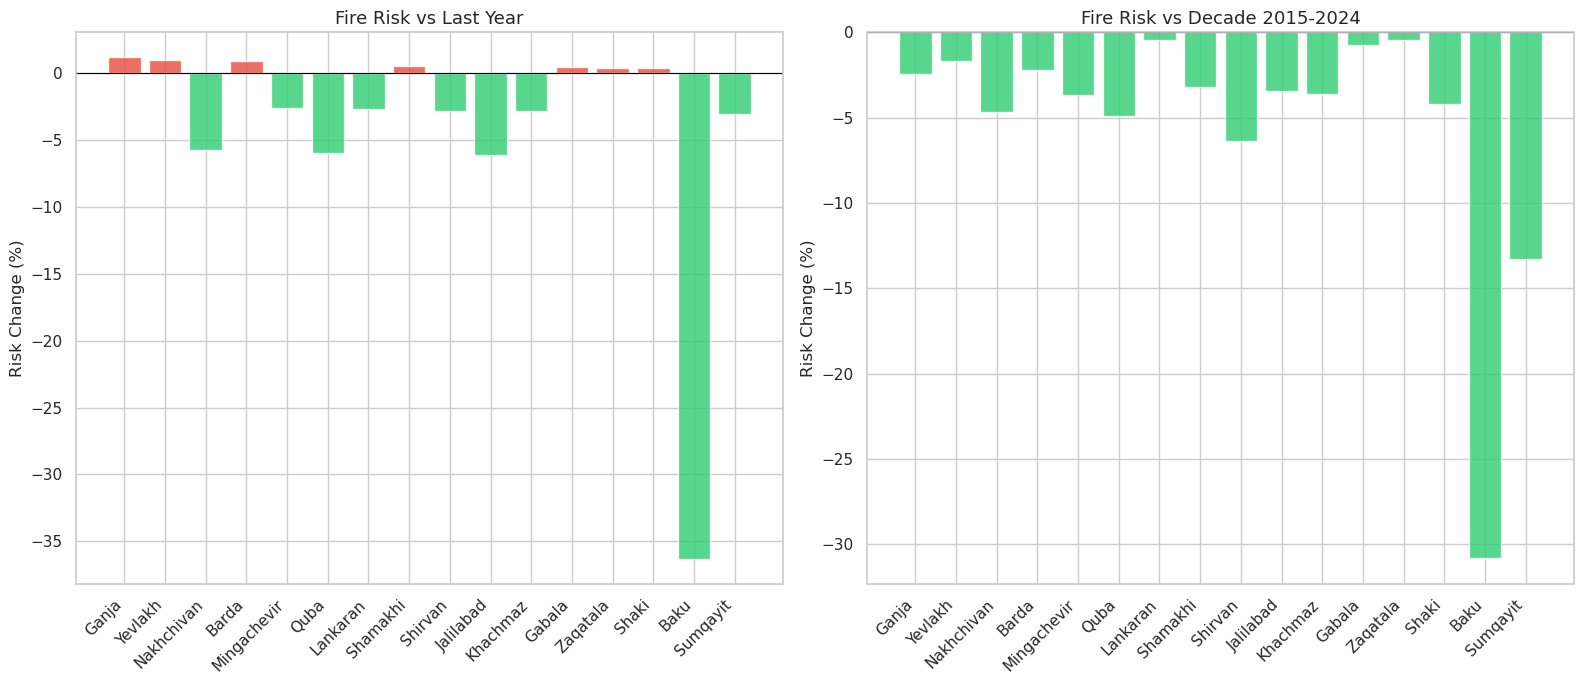

Cities with INCREASING risk: 7/16


In [5]:
# ─── §4: Risk comparison — forecast vs historical ────────────────────────
fc_risk = risk.groupby("City")["fire_probability"].mean()
ly_fire = hist[(hist["Date"] >= ly_start) & (hist["Date"] <= ly_end)]
ly_fr = ly_fire.groupby("City")["Fire_Occurred"].mean() if "Fire_Occurred" in ly_fire.columns else pd.Series(dtype=float)
dec_fire = hist[(hist["Year"]>=DECADE_START)&(hist["Year"]<=DECADE_END)&(hist["Month"].isin(fc_months))]
dec_fr = dec_fire.groupby("City")["Fire_Occurred"].mean() if "Fire_Occurred" in dec_fire.columns else pd.Series(dtype=float)

rc = pd.DataFrame({"Forecast_Risk":fc_risk, "LastYear":ly_fr, "Decade":dec_fr}).dropna()
rc["vs_LY"] = rc["Forecast_Risk"] - rc["LastYear"]
rc["vs_Dec"] = rc["Forecast_Risk"] - rc["Decade"]
rc = rc.sort_values("Forecast_Risk", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for i, (col, title) in enumerate([("vs_LY","vs Last Year"),("vs_Dec",f"vs Decade {DECADE_START}-{DECADE_END}")]):
    ax = axes[i]
    ax.bar(range(len(rc)), rc[col]*100,
           color=["#e74c3c" if v>0 else "#2ecc71" for v in rc[col]], alpha=0.8)
    ax.set_xticks(range(len(rc))); ax.set_xticklabels(rc.index, rotation=45, ha="right")
    ax.set_ylabel("Risk Change (%)"); ax.set_title(f"Fire Risk {title}", fontsize=13)
    ax.axhline(0, color="black", lw=0.8)
plt.tight_layout(); plt.savefig(FIGURES / "climate_risk_comparison.png", dpi=150); plt.show()
rc.to_csv(METRICS / "risk_comparison.csv")
print(f"Cities with INCREASING risk: {((rc['vs_LY']>0)|(rc['vs_Dec']>0)).sum()}/{len(rc)}")

## §5 — Final Jury Summary

In [ ]:
# ─── §5: Conclusion ────────────────────────────────────────
print("=" * 70)
print("   AZERBAIJAN WILDFIRE & CLIMATE INTELLIGENCE — KEY FINDINGS")
print("=" * 70)

print("\n🔥 HIGHEST RISK CITIES (next 30 days):")
for i, (city, row) in enumerate(rc.head(5).iterrows(), 1):
    print(f"   {i}. {city} — {row['Forecast_Risk']*100:.1f}% avg daily fire probability")

if "comp" in dir() and "Diff" in comp.columns:
    print("\n🌡 TEMPERATURE vs LAST YEAR:")
    for city, row in comp.head(5).iterrows():
        print(f"   {city}: {row['Forecast']:.1f}°C ({row['Diff']:+.1f}°C)")

print("\n📈 BIGGEST RISK INCREASES:")
for city, row in rc.nlargest(5, "vs_LY").iterrows():
    print(f"   {city}: {row['vs_LY']*100:+.1f}% vs last year")

print("\n📊 CLIMATE SIGNALS:")
for k, v in trends.items():
    label = k.replace("_", " ").title()
    direction = "increasing" if v > 0 else "decreasing"
    print(f"   • {label}: {v:+.4f} ({direction})")

print("\n🔑 MAIN FIRE RISK DRIVERS:")
print("   1. High temperature + low humidity combination")
print("   2. Extended dry periods (consecutive days without rain)")
print("   3. High wind speed during dry conditions")
print("   4. Seasonal pattern — peak risk May–September")
print("   5. Vegetation density under drought stress")

print("\n⚠ NOTE: These are statistical signals and model predictions,")
print("   not deterministic forecasts. Local conditions can change outcomes.")

# Save summary CSV
summary = []
for city, row in rc.iterrows():
    summary.append({"City": city,
        "Risk_%": round(row["Forecast_Risk"]*100, 1),
        "vs_LY_%": round(row["vs_LY"]*100, 1),
        "vs_Dec_%": round(row["vs_Dec"]*100, 1)})
pd.DataFrame(summary).to_csv(METRICS / "climate_summary.csv", index=False)

print(f"\n{'='*70}")
print(f"  Outputs: {METRICS}")
print(f"  Figures: {FIGURES}")
print(f"{'='*70}")

   AZERBAIJAN WILDFIRE & CLIMATE INTELLIGENCE — KEY FINDINGS

🔥 HIGHEST RISK CITIES (next 30 days):
   1. Ganja — 1.2% avg daily fire probability
   2. Yevlakh — 1.0% avg daily fire probability
   3. Nakhchivan — 0.9% avg daily fire probability
   4. Barda — 0.9% avg daily fire probability
   5. Mingachevir — 0.8% avg daily fire probability

🌡 TEMPERATURE vs LAST YEAR:
   Lankaran: 19.5°C (+1.1°C)
   Jalilabad: 19.3°C (+1.0°C)
   Shirvan: 20.6°C (+0.8°C)
   Yevlakh: 21.0°C (+0.7°C)
   Mingachevir: 21.0°C (+0.6°C)

📈 BIGGEST RISK INCREASES:
   Ganja: +1.2% vs last year
   Yevlakh: +1.0% vs last year
   Barda: +0.9% vs last year
   Shamakhi: +0.5% vs last year
   Gabala: +0.4% vs last year

📊 CLIMATE SIGNALS:
   • Temp Trend Per Year: -0.1377 (decreasing)
   • Extreme Heat Trend: +1.5571 (increasing)
   • Precip Trend: -5.9929 (decreasing)
   • Fire Trend: -14.5429 (decreasing)

🔑 MAIN FIRE RISK DRIVERS:
   1. High temperature + low humidity combination
   2. Extended dry periods (consec